<a href="https://colab.research.google.com/github/varshamqa/AIML_Practice_Repo_VSC1/blob/main/AI_ML_PCA_Varsha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from mpl_toolkits.mplot3d import Axes3D

In [2]:
data = pd.read_csv('/content/kidney_disease.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [4]:
data.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Chronic Kidney Disease Dataset - Column Description</title>

<style>
    body{
        font-family: Arial, Helvetica, sans-serif;
        background:#f4f6f9;
        margin:40px;
    }

    h2{
        text-align:center;
        color:#1f4e79;
        margin-bottom:25px;
    }

    table{
        width:100%;
        border-collapse:collapse;
        box-shadow:0 0 15px rgba(0,0,0,0.15);
        background:white;
    }

    th{
        background:#1f4e79;
        color:white;
        padding:14px;
        text-align:left;
        font-size:16px;
    }

    td{
        padding:12px;
        border-bottom:1px solid #ddd;
        vertical-align:top;
    }

    tr:nth-child(even){
        background:#f9f9f9;
    }

    tr:hover{
        background:#eef6ff;
    }

    caption{
        caption-side:bottom;
        margin-top:15px;
        font-style:italic;
        color:gray;
    }
</style>

</head>

<body>

<h2>Chronic Kidney Disease (CKD) Dataset - Column Description</h2>

<table>

<thead>
<tr>
    <th>Column</th>
    <th>Full Form</th>
    <th>Description</th>
    <th>Normal Range / Meaning</th>
</tr>
</thead>

<tbody>

<tr>
<td><b>age</b></td>
<td>Age</td>
<td>Age of the patient (years)</td>
<td>1–100 years</td>
</tr>

<tr>
<td><b>bp</b></td>
<td>Blood Pressure</td>
<td>Blood pressure measured in mmHg</td>
<td>Around 120/80 mmHg is considered normal</td>
</tr>

<tr>
<td><b>sg</b></td>
<td>Specific Gravity</td>
<td>Measures urine concentration and kidney filtering ability</td>
<td>1.005 – 1.025</td>
</tr>

<tr>
<td><b>al</b></td>
<td>Albumin</td>
<td>Amount of albumin (protein) present in urine</td>
<td>Normally 0</td>
</tr>

<tr>
<td><b>su</b></td>
<td>Sugar</td>
<td>Sugar (glucose) present in urine</td>
<td>Normally 0</td>
</tr>

<tr>
<td><b>rbc</b></td>
<td>Red Blood Cells</td>
<td>Whether RBCs in urine are normal or abnormal</td>
<td>normal / abnormal</td>
</tr>

<tr>
<td><b>pc</b></td>
<td>Pus Cell</td>
<td>Indicates infection by checking pus cells in urine</td>
<td>normal / abnormal</td>
</tr>

<tr>
<td><b>pcc</b></td>
<td>Pus Cell Clumps</td>
<td>Presence of pus cell clumps</td>
<td>present / notpresent</td>
</tr>

<tr>
<td><b>ba</b></td>
<td>Bacteria</td>
<td>Presence of bacteria in urine</td>
<td>present / notpresent</td>
</tr>

<tr>
<td><b>bgr</b></td>
<td>Blood Glucose Random</td>
<td>Random blood sugar level</td>
<td>Around 70–140 mg/dL</td>
</tr>

<tr>
<td><b>bu</b></td>
<td>Blood Urea</td>
<td>Measures waste products in blood</td>
<td>7–20 mg/dL</td>
</tr>

<tr>
<td><b>sc</b></td>
<td>Serum Creatinine</td>
<td>Indicates kidney filtration efficiency</td>
<td>0.6–1.2 mg/dL</td>
</tr>

<tr>
<td><b>sod</b></td>
<td>Sodium</td>
<td>Sodium level in blood</td>
<td>135–145 mEq/L</td>
</tr>

<tr>
<td><b>pot</b></td>
<td>Potassium</td>
<td>Potassium level in blood</td>
<td>3.5–5.0 mEq/L</td>
</tr>

<tr>
<td><b>hemo</b></td>
<td>Hemoglobin</td>
<td>Oxygen-carrying protein in blood</td>
<td>Male: 13.5–17.5 g/dL</td>
</tr>

<tr>
<td><b>pcv</b></td>
<td>Packed Cell Volume</td>
<td>Percentage of blood occupied by RBCs</td>
<td>40–54%</td>
</tr>

<tr>
<td><b>wc</b></td>
<td>White Blood Cell Count</td>
<td>Number of WBCs</td>
<td>4,000–11,000 cells/µL</td>
</tr>

<tr>
<td><b>rc</b></td>
<td>Red Blood Cell Count</td>
<td>Number of RBCs</td>
<td>Male: 4.5–5.9 million/µL</td>
</tr>

<tr>
<td><b>htn</b></td>
<td>Hypertension</td>
<td>Whether patient has high blood pressure</td>
<td>yes / no</td>
</tr>

<tr>
<td><b>dm</b></td>
<td>Diabetes Mellitus</td>
<td>Whether patient has diabetes</td>
<td>yes / no</td>
</tr>

<tr>
<td><b>cad</b></td>
<td>Coronary Artery Disease</td>
<td>Whether patient has heart disease</td>
<td>yes / no</td>
</tr>

<tr>
<td><b>appet</b></td>
<td>Appetite</td>
<td>Patient's appetite</td>
<td>good / poor</td>
</tr>

<tr>
<td><b>pe</b></td>
<td>Pedal Edema</td>
<td>Swelling in feet or ankles</td>
<td>yes / no</td>
</tr>

<tr>
<td><b>ane</b></td>
<td>Anemia</td>
<td>Whether patient has anemia</td>
<td>yes / no</td>
</tr>

<tr>
<td><b>classification</b></td>
<td>Target Variable</td>
<td>Whether patient has Chronic Kidney Disease</td>
<td>ckd / notckd</td>
</tr>

</tbody>

<caption>
Chronic Kidney Disease (CKD) Dataset Attribute Description
</caption>

</table>

</body>
</html>

In [5]:
data.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [6]:
data.isnull().sum()

,0
id,0
age,9
bp,12
sg,47
al,46
su,49
rbc,152
pc,65
pcc,4
ba,4


In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
from typing_extensions import ValuesView
# #TODO
# Graph1: Visualize the missing values count in a bar chart
# Graph 2: Heatmap of Missing ValuesView
# Graph 3: Visualization of distribution of columns (Numerical ad Categorical)
# Graph 4: Numerical cols boxplots

/tmp/ipykernel_1345/1933233662.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')


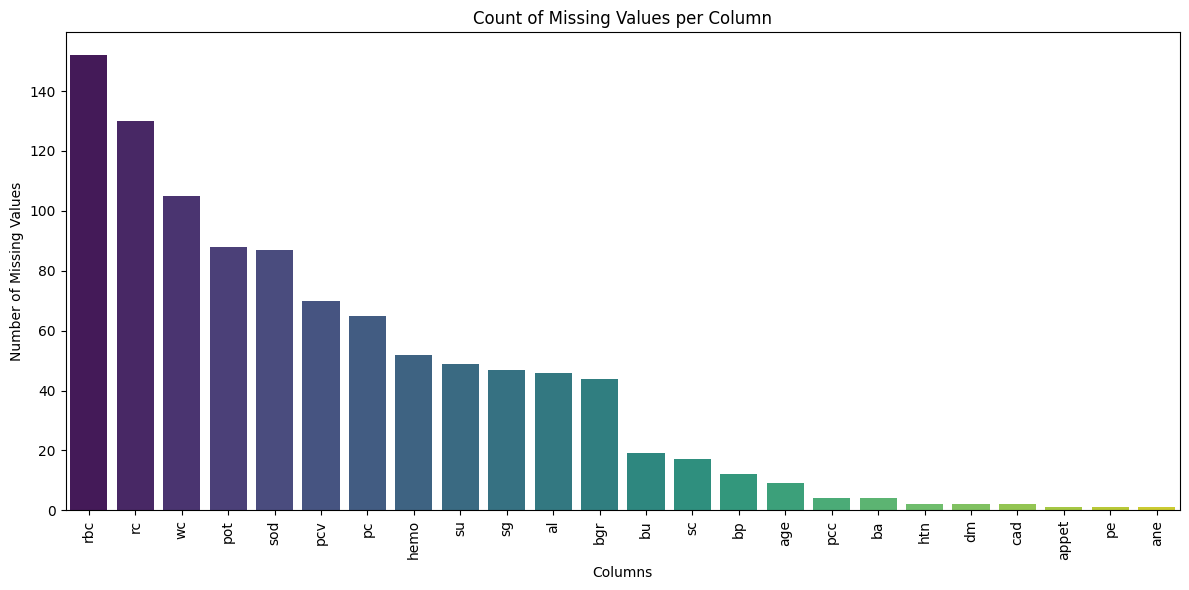

In [9]:
missing_values = data.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')
plt.title('Count of Missing Values per Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

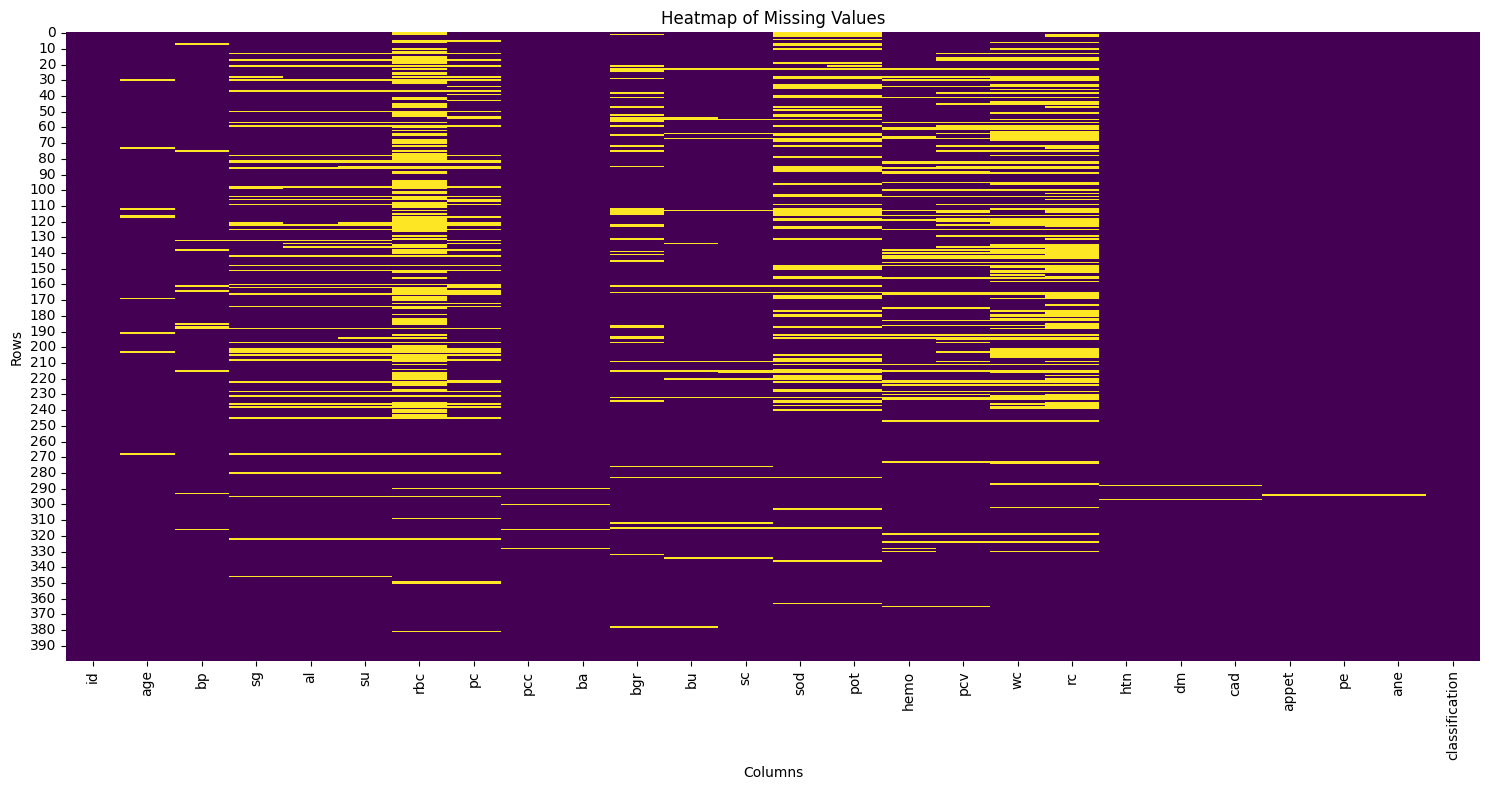

In [10]:
plt.figure(figsize=(15, 8))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()

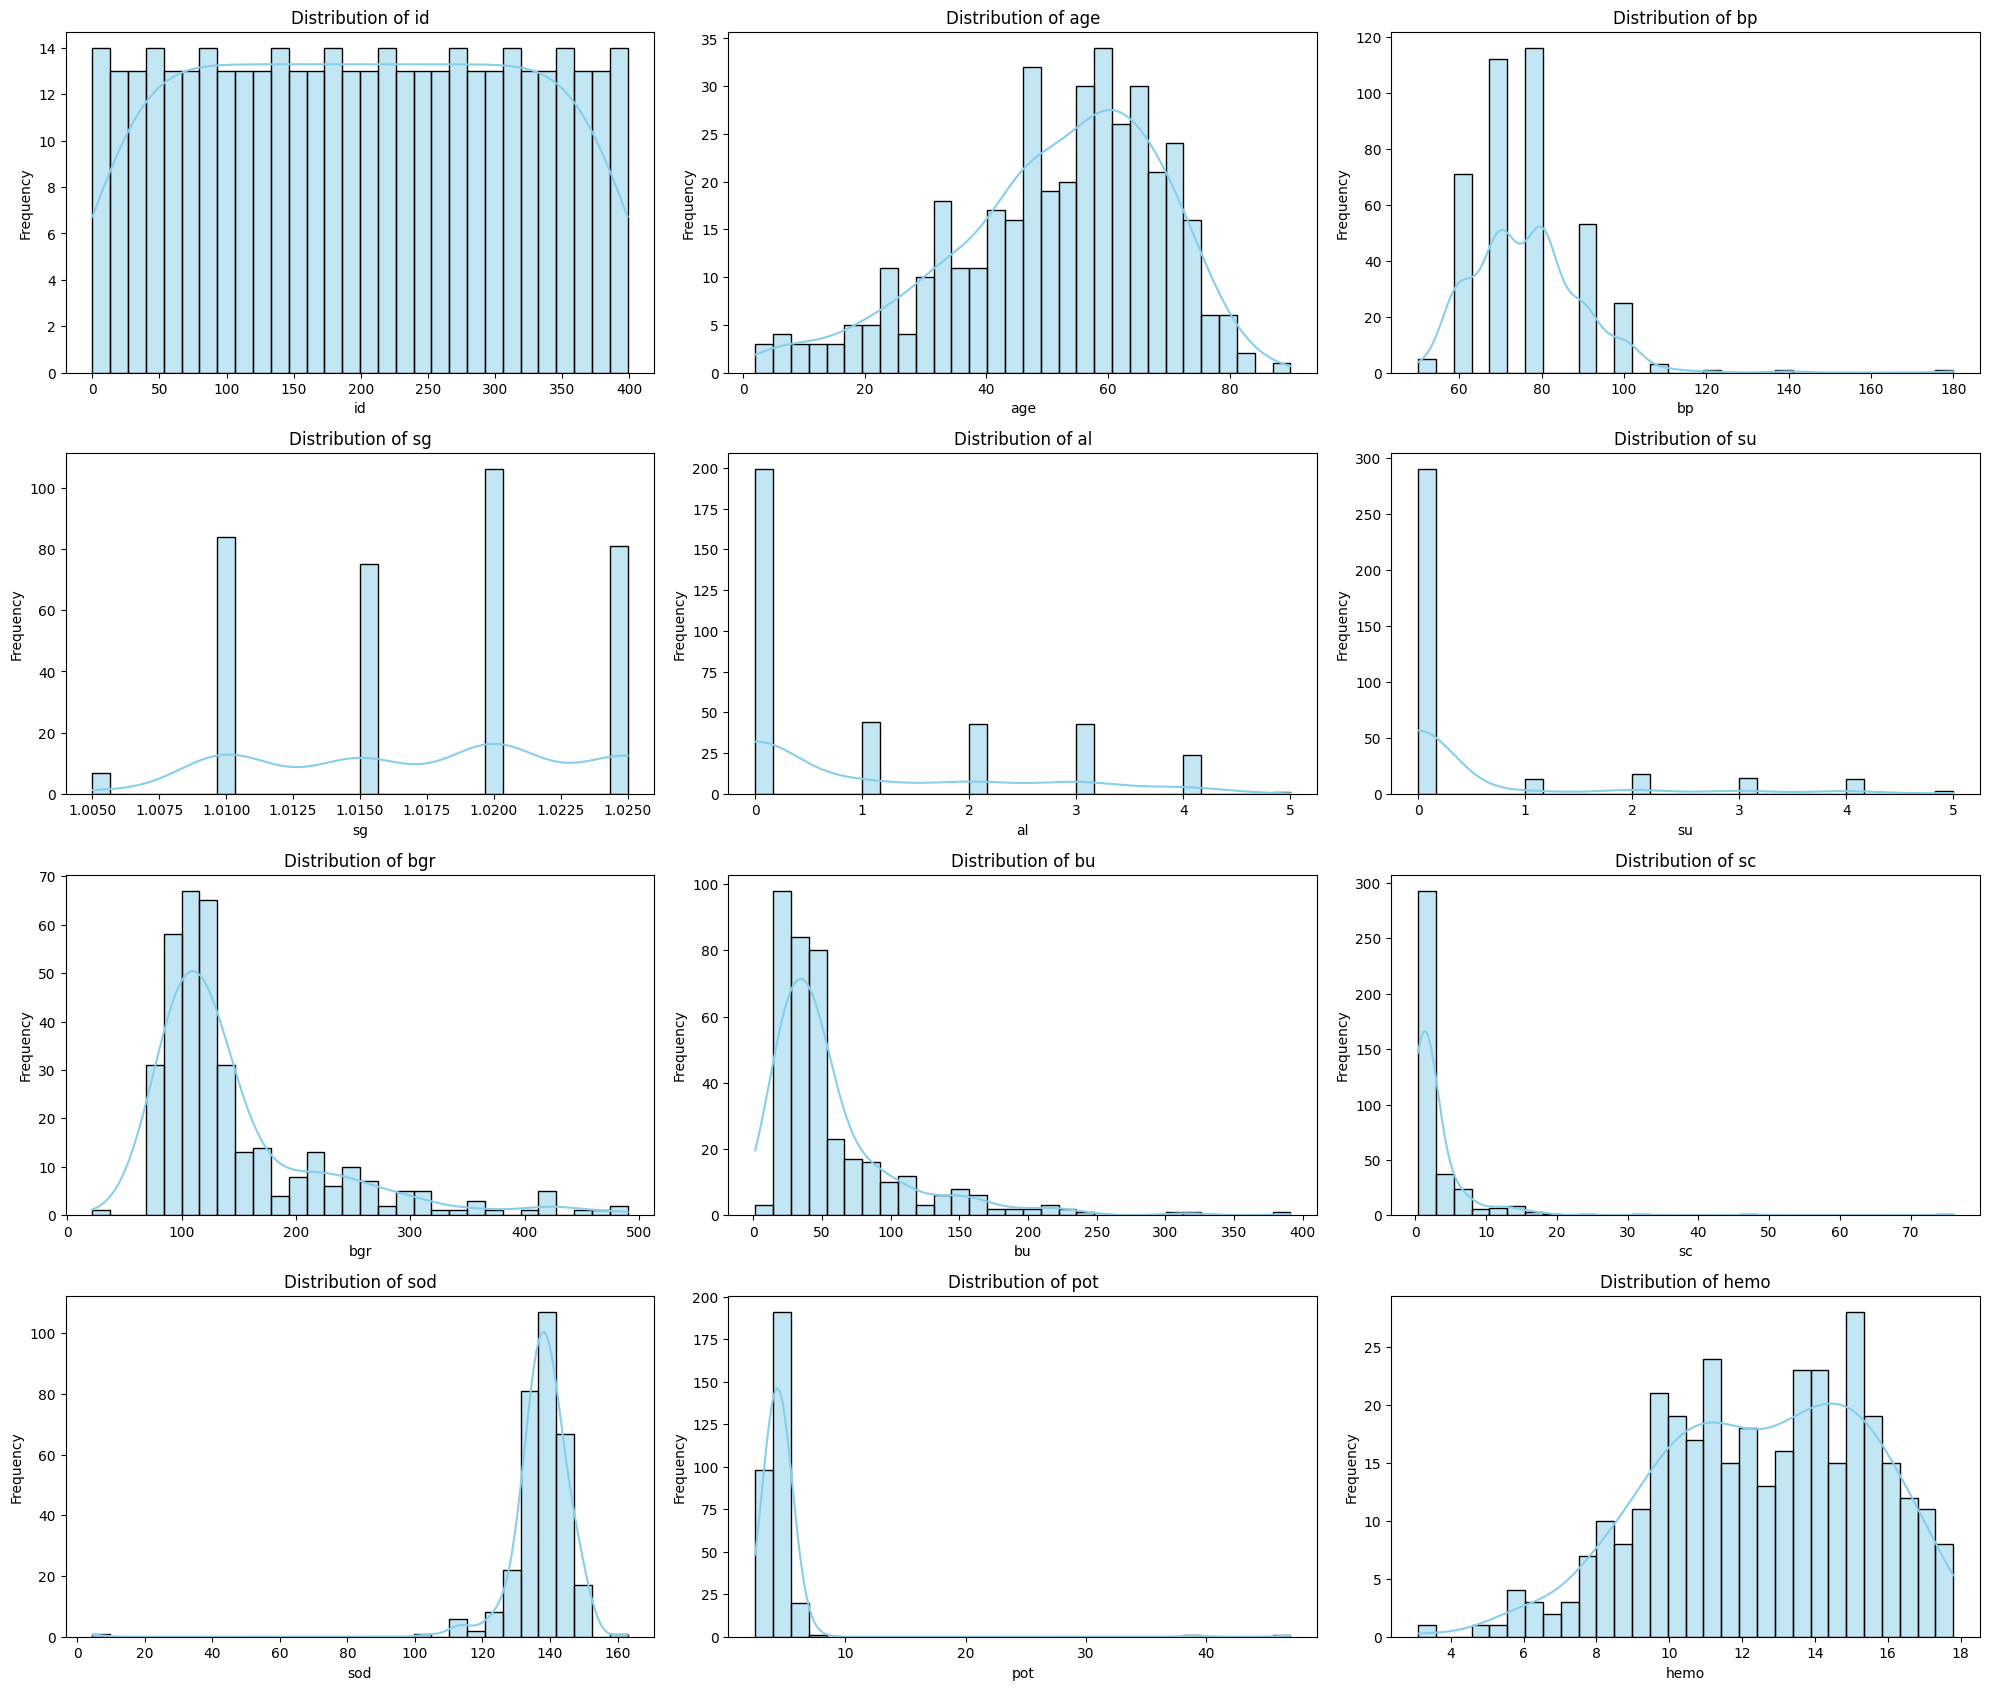

In [11]:
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns.tolist()

plt.figure(figsize=(20, 25))
for i, col in enumerate(numerical_cols):
    plt.subplot(6, 3, i + 1) # Adjust subplot grid as needed based on number of numerical columns
    sns.histplot(data[col].dropna(), kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

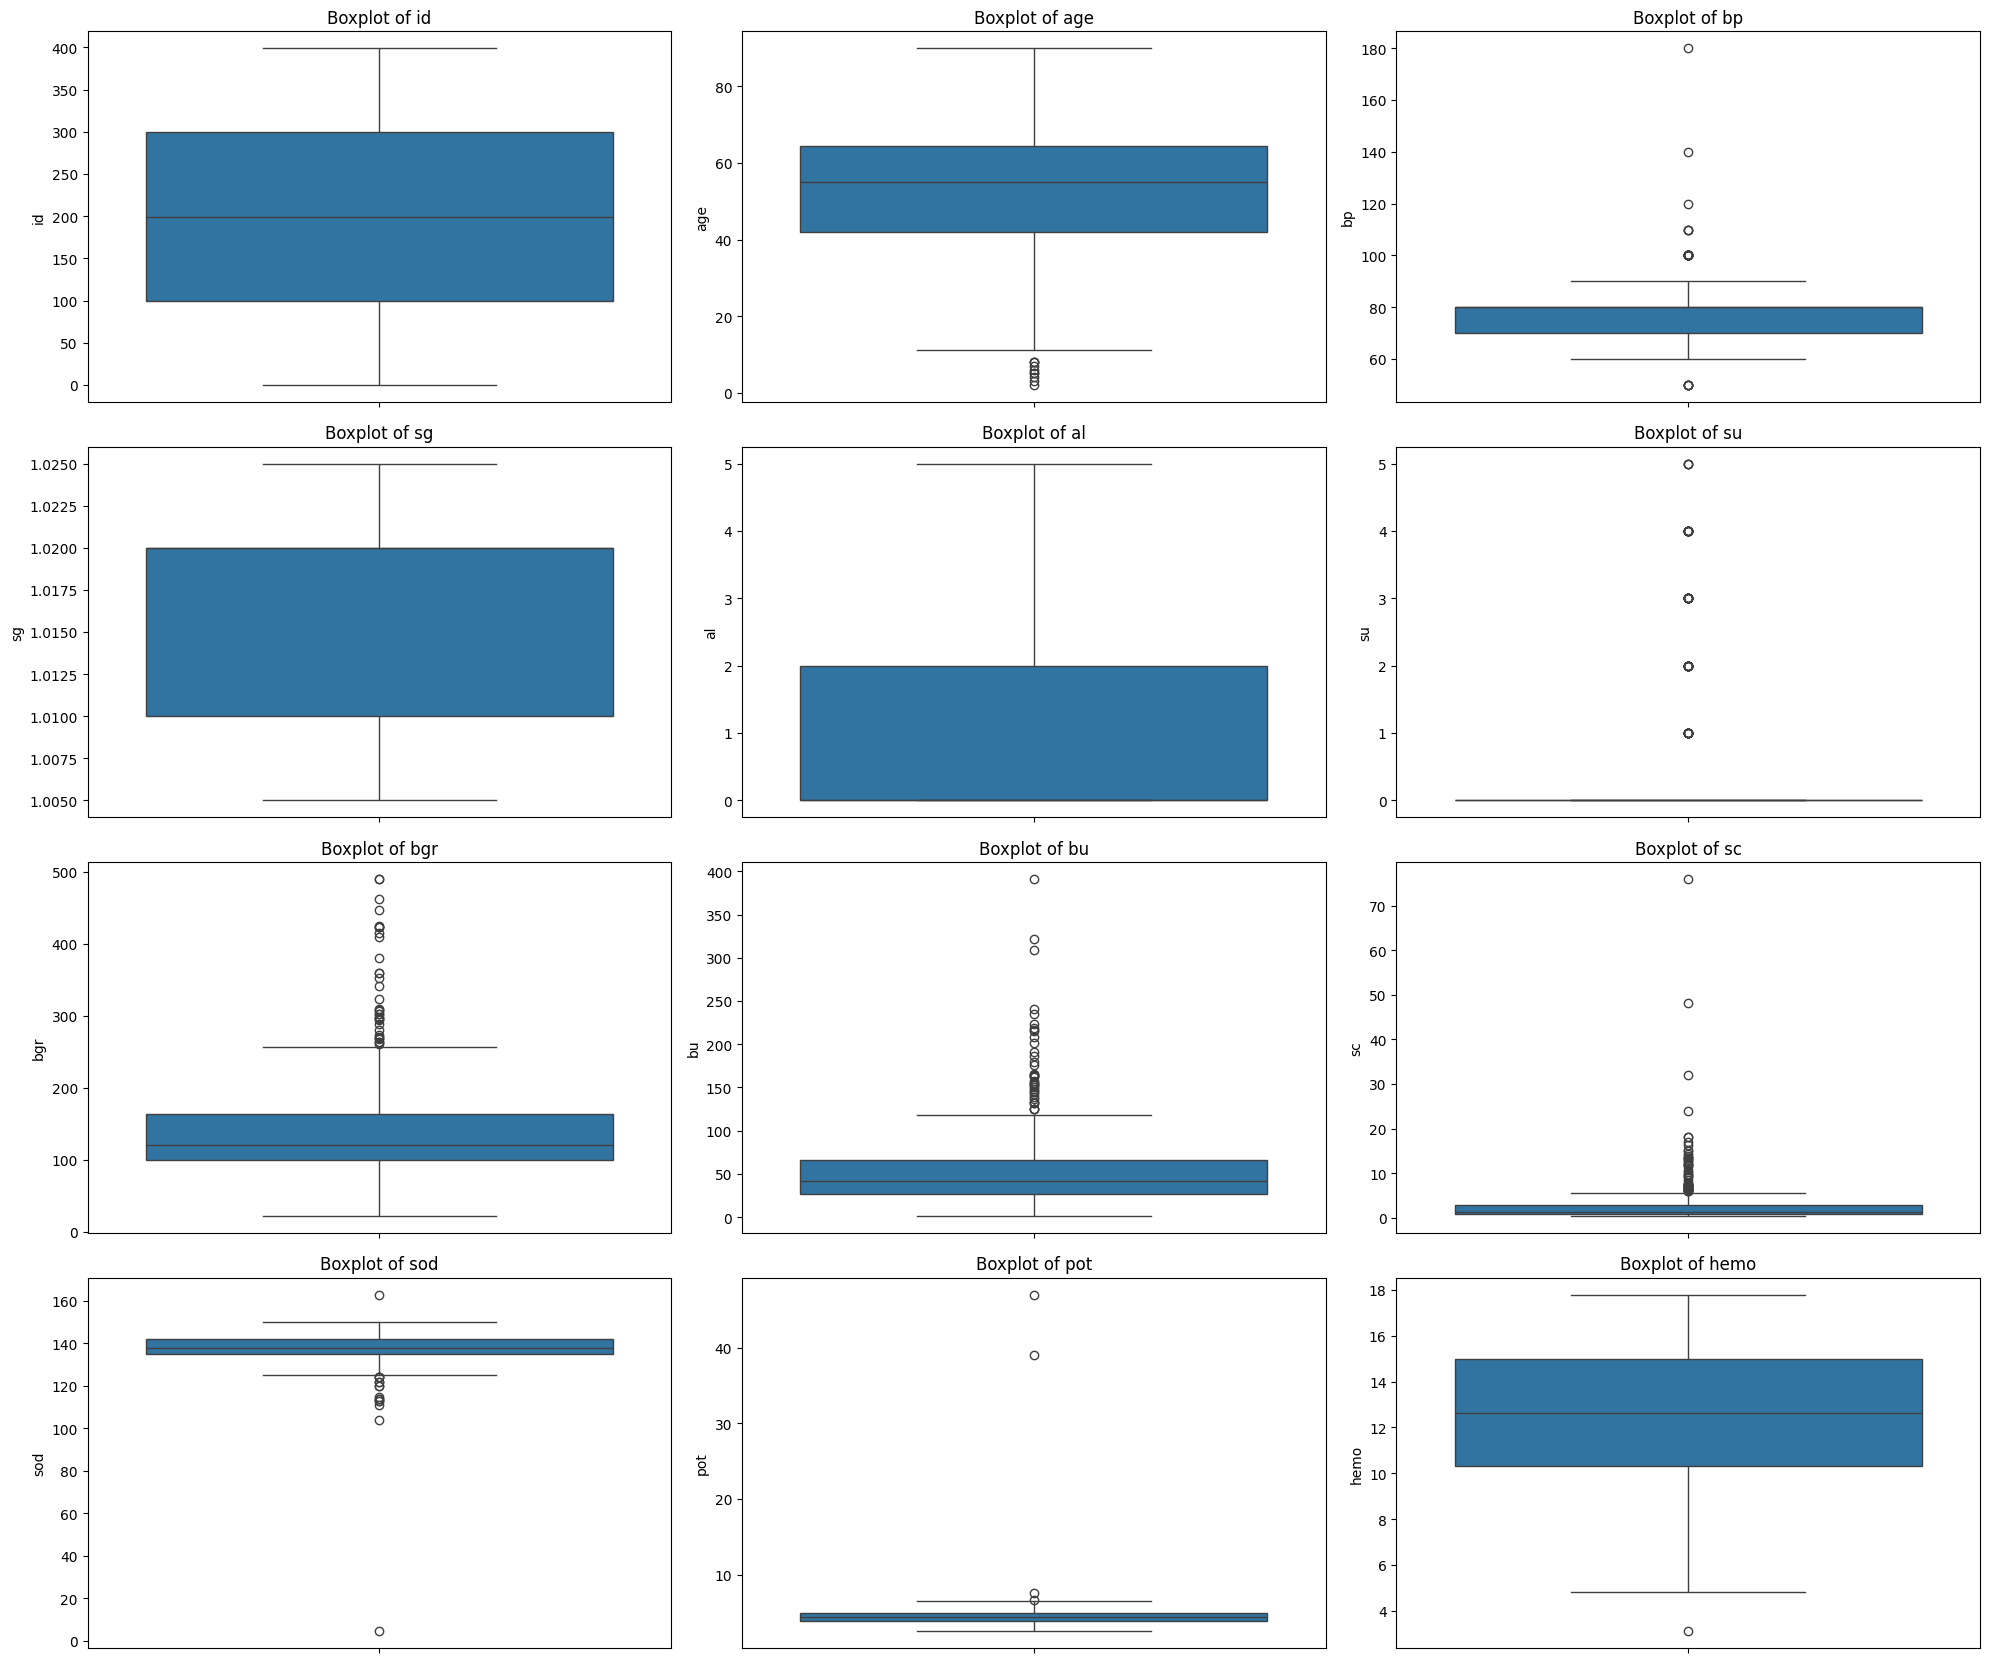

In [12]:
plt.figure(figsize=(20, 25))
for i, col in enumerate(numerical_cols):
    plt.subplot(6, 3, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [13]:
data.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [14]:
data.columns = data.columns.str.strip()

In [15]:
data.replace('?', np.nan, inplace = True)

In [16]:
data.dtypes

,0
id,int64
age,float64
bp,float64
sg,float64
al,float64
su,float64
rbc,object
pc,object
pcc,object
ba,object


In [17]:
numeric_columns = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']

In [18]:
for col in numeric_columns:
  data[col] = pd.to_numeric(data[col], errors = 'coerce')

In [19]:
data.drop('id', axis =1, inplace=True)

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    object 
 6   pc              335 non-null    object 
 7   pcc             396 non-null    object 
 8   ba              396 non-null    object 
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-null    float64
 12  sod             313 non-null    float64
 13  pot             312 non-null    float64
 14  hemo            348 non-null    float64
 15  pcv             329 non-null    float64
 16  wc              294 non-null    float64
 17  rc              269 non-null    flo

In [21]:
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = data.select_dtypes(include='object').columns

In [22]:
print(numeric_cols)
print(categorical_cols)

Index(['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo',
       'pcv', 'wc', 'rc'],
      dtype='object')
Index(['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane',
       'classification'],
      dtype='object')


In [23]:
num_imputer = SimpleImputer(strategy='median')
data[numeric_cols] = num_imputer.fit_transform(data[numeric_cols])
cat_imputer = SimpleImputer(strategy='most_frequent')
data[categorical_cols] = cat_imputer.fit_transform(data[categorical_cols])

In [24]:
data.isnull().sum()

,0
age,0
bp,0
sg,0
al,0
su,0
rbc,0
pc,0
pcc,0
ba,0
bgr,0


In [25]:
data.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,121.0,...,38.0,6000.0,4.8,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,4.8,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [26]:
data = data.replace({
    ' yes':'yes',
    '\tyes':'yes',
    ' yes ':'yes',
    'no ':'no',
    '\tno':'no',
    'ckd\t':'ckd'
})

In [27]:
for col in categorical_cols:
  print(col)
  print(data[col].unique())
  print("-"*50)

rbc
['normal' 'abnormal']
--------------------------------------------------
pc
['normal' 'abnormal']
--------------------------------------------------
pcc
['notpresent' 'present']
--------------------------------------------------
ba
['notpresent' 'present']
--------------------------------------------------
htn
['yes' 'no']
--------------------------------------------------
dm
['yes' 'no']
--------------------------------------------------
cad
['no' 'yes']
--------------------------------------------------
appet
['good' 'poor']
--------------------------------------------------
pe
['no' 'yes']
--------------------------------------------------
ane
['no' 'yes']
--------------------------------------------------
classification
['ckd' 'notckd']
--------------------------------------------------


In [28]:
encoder = LabelEncoder()
for col in categorical_cols:
  data[col] = encoder.fit_transform(data[col])

In [29]:
data.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,0,0,0,0
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,0,0,0,0,0,0
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,1,0,1,0,1,0
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,1,1,1,0
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,0,0,0,0


In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             400 non-null    float64
 1   bp              400 non-null    float64
 2   sg              400 non-null    float64
 3   al              400 non-null    float64
 4   su              400 non-null    float64
 5   rbc             400 non-null    int64  
 6   pc              400 non-null    int64  
 7   pcc             400 non-null    int64  
 8   ba              400 non-null    int64  
 9   bgr             400 non-null    float64
 10  bu              400 non-null    float64
 11  sc              400 non-null    float64
 12  sod             400 non-null    float64
 13  pot             400 non-null    float64
 14  hemo            400 non-null    float64
 15  pcv             400 non-null    float64
 16  wc              400 non-null    float64
 17  rc              400 non-null    flo

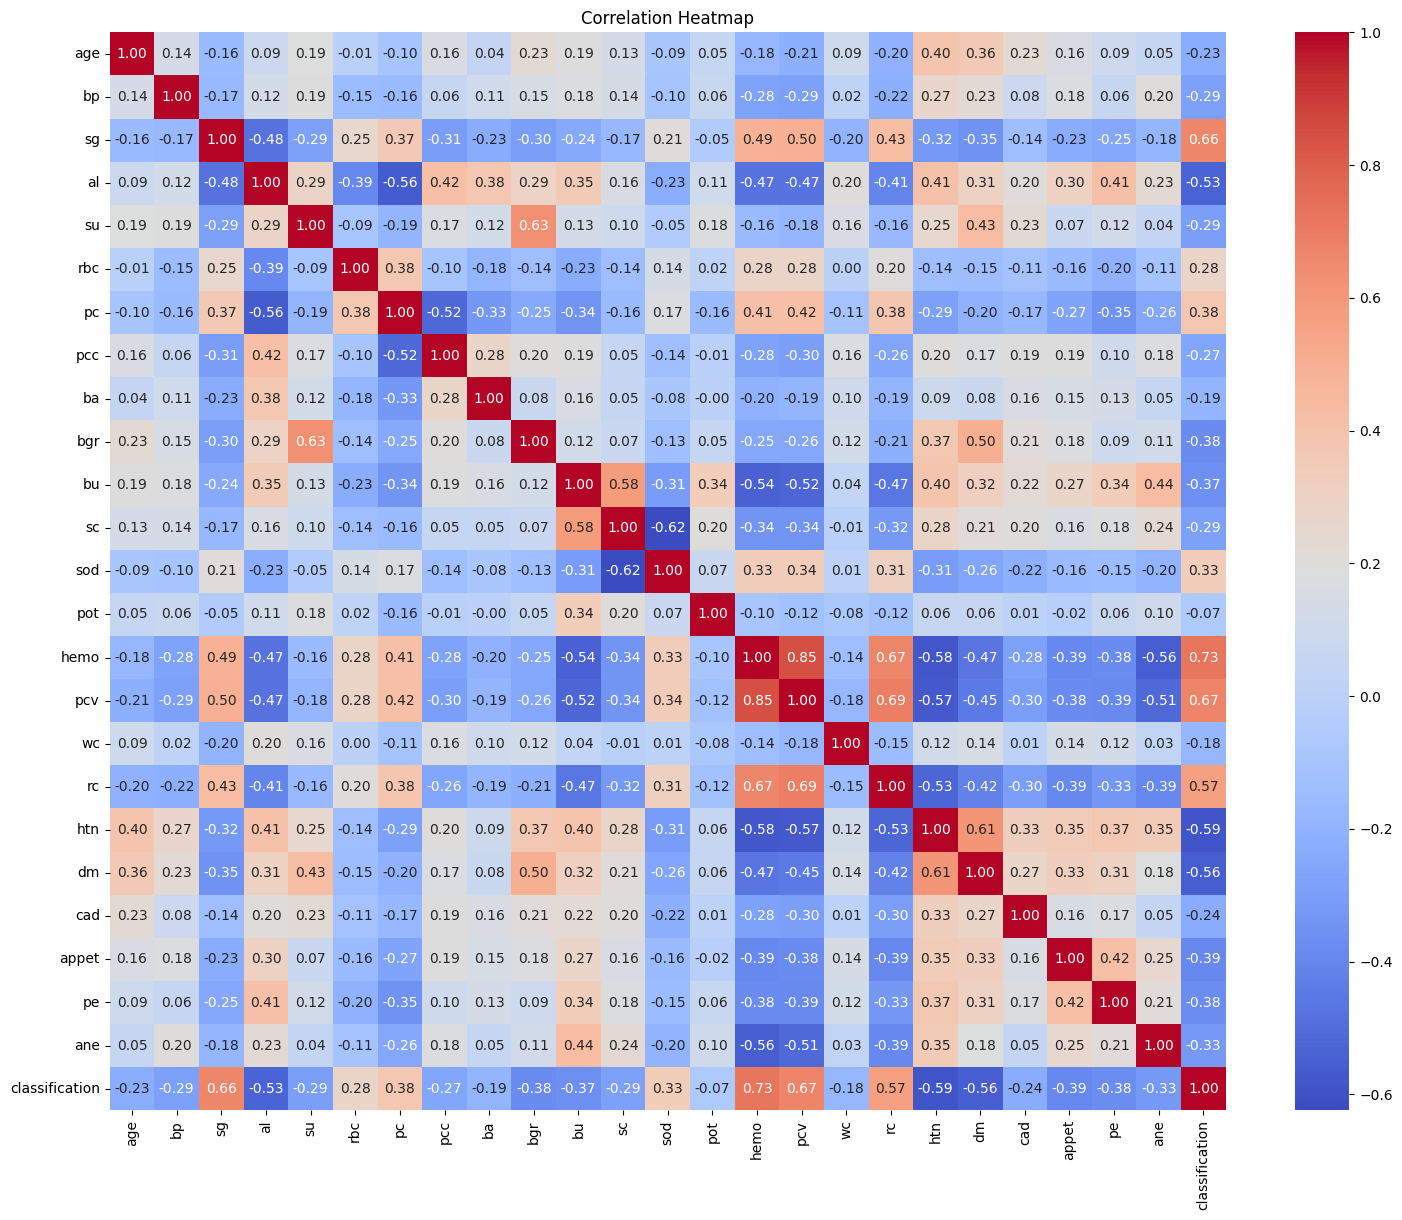

In [31]:
corr = data.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [32]:
# #TODO
# generate Insights to this heatmap and write it her

### Insights from the Correlation Heatmap

The correlation heatmap provides valuable insights into the relationships between features and with the target variable ('classification').

**1. Correlations with 'classification' (Target Variable):**
   *   **Strong Negative Correlations with 'classification'**: Features like `hemo` (hemoglobin), `rc` (red blood cell count), `pcv` (packed cell volume), `sg` (specific gravity), `al` (albumin), `sod` (sodium) and `pot` (potassium) show strong negative correlations with 'classification'. This suggests that lower values in these features are associated with Chronic Kidney Disease (CKD).
   *   **Strong Positive Correlations with 'classification'**: `bp` (blood pressure), `bu` (blood urea), `sc` (serum creatinine), `bgr` (blood glucose random), `dm` (diabetes mellitus), `htn` (hypertension), `pe` (pedal edema), `ane` (anemia), `rbc` (red blood cells), `pc` (pus cell) and `wc` (white blood cell count) show notable positive correlations. Higher values or presence of these conditions are associated with CKD.

**2. Inter-Feature Correlations:**
   *   **High Positive Correlations:**
      *   `hemo`, `rc`, and `pcv` are highly positively correlated with each other, which is expected as they are all related to red blood cell parameters (e.g., `hemo` and `pcv` have a correlation of 0.90).
      *   `bu` (blood urea) and `sc` (serum creatinine) are positively correlated (0.59), indicating they both measure kidney function.
      *   `dm` (diabetes mellitus) and `htn` (hypertension) are moderately positively correlated.
   *   **High Negative Correlations:**
      *   `al` (albumin) is negatively correlated with `sg` (-0.48), suggesting that higher albumin in urine (a sign of kidney damage) is associated with lower specific gravity.
      *   `sg` is also negatively correlated with `bu` (-0.49) and `sc` (-0.43).
   *   **Moderate Correlations:**
      *   `age` shows a moderate positive correlation with `bp`, `bu`, `sc`, `dm`, `htn`, and `cad`, and a moderate negative correlation with `hemo` and `sg`. This indicates that age can be a contributing factor to the progression of CKD and related conditions.

**3. Less Correlated Features:**
   *   Features like `pcc` (pus cell clumps) and `ba` (bacteria) show very low correlations with most other features, including the target variable, suggesting they might have less predictive power on their own or their relationship is more complex than linear correlation can capture.

Overall, the heatmap highlights key diagnostic indicators and risk factors for Chronic Kidney Disease, confirming known medical relationships and pointing to features that are highly interdependent.

In [33]:
from sklearn.utils import column_or_1d
threshold = 0.80
corr_matrix = data.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column
    for column in upper.columns
    if any(upper[column] > threshold)
]
print(high_corr)

['pcv']


In [34]:
X = data.drop('classification', axis=1)
y = data['classification']

In [35]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [36]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
0,-0.210031,0.254214,0.421486,0.076249,-0.380269,0.36489,0.484322,-0.342518,-0.241249,-0.320122,...,1.053226,0.603224,-0.197314,0.550044,1.311903,1.385535,-0.304789,-0.507801,-0.484322,-0.420084
1,-2.627234,-1.972476,0.421486,2.363728,-0.380269,0.36489,0.484322,-0.342518,-0.241249,-0.320122,...,-0.457965,-0.132789,-0.909782,0.074073,-0.762252,-0.721743,-0.304789,-0.507801,-0.484322,-0.420084
2,0.615355,0.254214,-1.421074,0.838742,2.507853,0.36489,0.484322,-0.342518,-0.241249,3.697618,...,-1.084556,-0.991470,-0.316059,0.074073,-0.762252,1.385535,-0.304789,1.969276,-0.484322,2.380476
3,-0.210031,-0.488016,-2.342354,2.363728,-0.380269,0.36489,-2.064742,2.919556,-0.241249,-0.373337,...,-0.494823,-0.868801,-0.632711,-0.996862,1.311903,-0.721743,-0.304789,1.969276,2.064742,2.380476
4,-0.033163,0.254214,-1.421074,0.838742,-0.380269,0.36489,0.484322,-0.342518,-0.241249,-0.519679,...,-0.347390,-0.500795,-0.395222,-0.163913,-0.762252,-0.721743,-0.304789,-0.507801,-0.484322,-0.420084


In [37]:
X_scaled.describe()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
count,400.000000,4.000000e+02,4.000000e+02,4.000000e+02,4.000000e+02,4.000000e+02,4.000000e+02,4.000000e+02,4.000000e+02,400.000000,...,4.000000e+02,4.000000e+02,4.000000e+02,4.000000e+02,4.000000e+02,4.000000e+02,4.000000e+02,4.000000e+02,4.000000e+02,400.000000
mean,0.000000,-2.309264e-16,3.183231e-14,3.552714e-17,-7.105427e-17,2.131628e-16,-1.421085e-16,1.776357e-17,-5.329071e-17,0.000000,...,-2.131628e-16,-4.263256e-16,-1.776357e-17,-2.486900e-16,3.552714e-17,-7.105427e-17,-9.769963e-17,-3.552714e-17,-1.776357e-17,0.000000
std,1.001252,1.001252e+00,1.001252e+00,1.001252e+00,1.001252e+00,1.001252e+00,1.001252e+00,1.001252e+00,1.001252e+00,1.001252,...,1.001252e+00,1.001252e+00,1.001252e+00,1.001252e+00,1.001252e+00,1.001252e+00,1.001252e+00,1.001252e+00,1.001252e+00,1.001252
min,-2.922015,-1.972476e+00,-2.342354e+00,-6.862436e-01,-3.802694e-01,-2.740554e+00,-2.064742e+00,-3.425178e-01,-2.412490e-01,-1.637196,...,-3.480346e+00,-3.690182e+00,-2.413881e+00,-3.138733e+00,-7.622517e-01,-7.217427e-01,-3.047887e-01,-5.078008e-01,-4.843221e-01,-0.420084
25%,-0.563768,-4.880162e-01,-4.997944e-01,-6.862436e-01,-3.802694e-01,3.648897e-01,4.843221e-01,-3.425178e-01,-2.412490e-01,-0.586198,...,-6.146124e-01,-6.234639e-01,-5.238618e-01,-2.829055e-01,-7.622517e-01,-7.217427e-01,-3.047887e-01,-5.078008e-01,-4.843221e-01,-0.420084
50%,0.202662,2.542138e-01,4.214856e-01,-6.862436e-01,-3.802694e-01,3.648897e-01,4.843221e-01,-3.425178e-01,-2.412490e-01,-0.320122,...,3.962269e-02,1.125486e-01,-1.181509e-01,7.407304e-02,-7.622517e-01,-7.217427e-01,-3.047887e-01,-5.078008e-01,-4.843221e-01,-0.420084
75%,0.733267,2.542138e-01,4.214856e-01,8.387421e-01,-3.802694e-01,3.648897e-01,4.843221e-01,-3.425178e-01,-2.412490e-01,0.065687,...,7.675744e-01,6.032235e-01,4.359907e-01,4.310515e-01,1.311903e+00,1.385535e+00,-3.047887e-01,-5.078008e-01,-4.843221e-01,-0.420084
max,2.266128,7.676514e+00,1.342766e+00,3.126221e+00,4.433268e+00,3.648897e-01,4.843221e-01,2.919556e+00,4.145096e+00,4.588971,...,1.937826e+00,1.829911e+00,7.164854e+00,3.881844e+00,1.311903e+00,1.385535e+00,3.280961e+00,1.969276e+00,2.064742e+00,2.380476


In [38]:
data.shape

(400, 25)

In [ ]:
X_scaled.shape

(400, 24)

In [39]:
y.shape

(400,)

In [40]:
from sklearn.decomposition import PCA
pca = PCA()

In [41]:
X_pca = pca.fit_transform(X_scaled)

In [42]:
explainedvariance = pca.explained_variance_ratio_
explainedvariance

array([0.28983122, 0.07940981, 0.07260893, 0.05507619, 0.05073854,
       0.04372456, 0.04266796, 0.04132766, 0.0367152 , 0.03327203,
       0.03272206, 0.0291274 , 0.02727032, 0.02484997, 0.02145516,
       0.01832877, 0.01768578, 0.0156815 , 0.01484749, 0.0137289 ,
       0.01200787, 0.01167289, 0.00927407, 0.00597574])

In [43]:
variance_data = pd.DataFrame({
    "Principal Component": np.arange(1, len(explainedvariance) + 1),
    "Explained Variance": explainedvariance
})

In [44]:
variance_data

,Principal Component,Explained Variance
0,1,0.289831
1,2,0.079410
2,3,0.072609
3,4,0.055076
4,5,0.050739
5,6,0.043725
6,7,0.042668
7,8,0.041328
8,9,0.036715
9,10,0.033272


In [45]:
eigen_values = pca.explained_variance_

eigen_values

array([6.97338272, 1.91061195, 1.7469818 , 1.32514131, 1.22077683,
       1.05201945, 1.02659744, 0.99434962, 0.88337312, 0.80052998,
       0.78729757, 0.70080956, 0.65612793, 0.59789404, 0.51621447,
       0.44099292, 0.42552264, 0.37729935, 0.35723274, 0.33031942,
       0.2889111 , 0.28085158, 0.22313552, 0.14377731])

In [46]:
eigen_data = pd.DataFrame({
    "Principal Component": np.arange(1, len(eigen_values) + 1),
    "Explained Variance": eigen_values
})

In [48]:
eigen_data

,Principal Component,Explained Variance
0,1,6.973383
1,2,1.910612
2,3,1.746982
3,4,1.325141
4,5,1.220777
5,6,1.052019
6,7,1.026597
7,8,0.994350
8,9,0.883373
9,10,0.800530


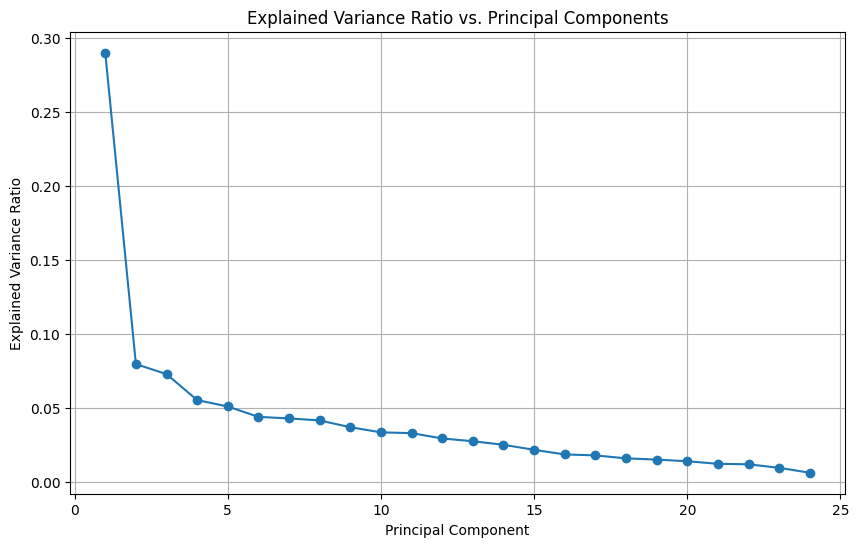

In [49]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(explainedvariance) + 1), explainedvariance, marker='o', linestyle='-')
plt.title('Explained Variance Ratio vs. Principal Components')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)

In [50]:
cumulative_variance = np.cumsum(explainedvariance)
cumulative_variance

array([0.28983122, 0.36924103, 0.44184996, 0.49692615, 0.54766468,
       0.59138924, 0.6340572 , 0.67538485, 0.71210005, 0.74537208,
       0.77809413, 0.80722153, 0.83449185, 0.85934182, 0.88079698,
       0.89912575, 0.91681153, 0.93249304, 0.94734052, 0.96106942,
       0.97307729, 0.98475019, 0.99402426, 1.        ])

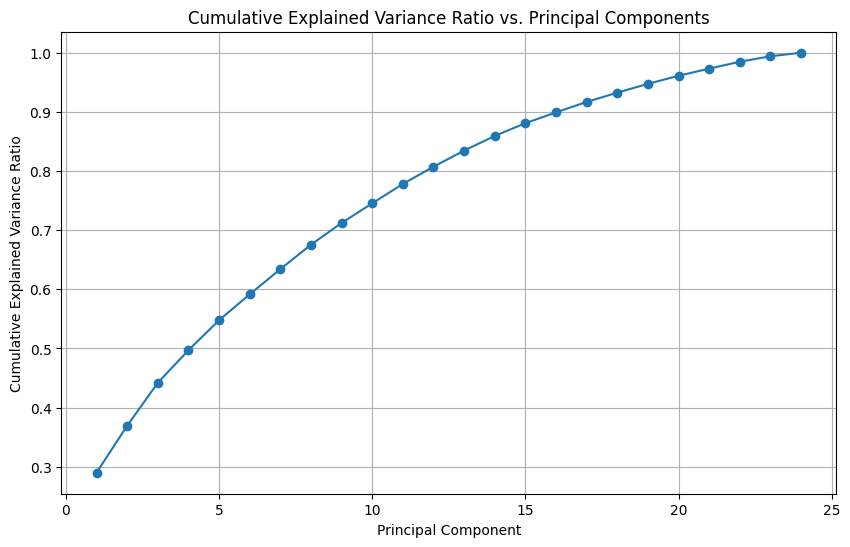

In [51]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance Ratio vs. Principal Components')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)

In [68]:
pca_95 = PCA(n_components=0.5)
X_pca_95 = pca_95.fit_transform(X_scaled)

print("Original Features: ", X_scaled.shape[1])
print("Reduced Features: ", X_pca_95.shape[1])

pca_95.components_

component_data = pd.DataFrame(
    pca_95.components_,
    columns=X_scaled.columns,
)
component_data

loading_scores = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(X.columns))],
    index=X.columns
)
loading_scores

Original Features:  24
Reduced Features:  5


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24
age,-0.129243,0.137850,0.317205,-0.087198,-0.081359,0.313625,0.003322,-0.373139,0.194947,-0.407359,...,-0.260260,-0.247083,-0.086869,0.027164,0.137527,-0.115062,-0.129639,-0.026622,0.024077,-0.045232
bp,-0.130832,-0.001281,0.117489,-0.001193,0.186375,-0.472468,-0.206535,-0.346767,0.539690,-0.074139,...,-0.053137,0.021001,0.025207,0.022634,-0.023041,-0.038111,-0.094024,0.124346,0.016487,-0.017020
sg,0.228965,-0.156743,0.115954,0.001793,-0.003158,0.110904,0.158055,-0.209264,0.011826,-0.099715,...,0.443464,-0.028642,-0.169986,0.122155,0.242669,-0.258973,-0.052189,-0.100087,0.067815,-0.020919
al,-0.255573,0.159011,-0.294407,0.110003,-0.023683,-0.003505,0.113743,0.111647,-0.031539,-0.007875,...,0.121325,-0.232188,0.497644,0.414688,0.089410,-0.127473,-0.402171,-0.051413,0.216790,0.024370
su,-0.148555,0.417274,0.254177,0.293113,0.104498,-0.087868,-0.004503,0.185501,-0.013836,0.118583,...,-0.263732,0.025911,-0.105993,0.217283,0.401372,0.129146,0.152752,-0.407110,-0.198872,-0.041208
rbc,0.144839,-0.022881,0.259266,-0.160260,0.096122,0.491414,-0.307247,0.033228,-0.034719,0.148614,...,-0.079352,-0.061438,-0.030091,0.107410,-0.208523,-0.064892,-0.208857,-0.140551,0.027194,0.015755
pc,0.230178,-0.105141,0.350714,-0.191595,-0.031404,-0.059961,-0.025351,0.110367,0.107965,0.279000,...,-0.101376,0.187681,0.422192,0.172551,0.371901,-0.235789,0.145366,0.384510,0.006974,-0.017709
pcc,-0.166714,0.200289,-0.278402,0.074608,-0.140245,0.296245,-0.355477,-0.175287,-0.211677,-0.327831,...,0.017384,0.376055,0.118632,-0.018403,0.255142,-0.110388,0.248490,0.227592,0.028011,-0.028215
ba,-0.123238,0.148024,-0.336374,0.155897,-0.181094,0.063878,-0.058857,-0.235111,0.372685,0.324979,...,0.055912,0.003742,-0.085649,-0.125280,0.004321,0.002638,0.125726,0.053905,-0.002336,0.026087
bgr,-0.173403,0.400250,0.264293,0.136277,0.033040,-0.174206,-0.021490,0.151505,-0.221381,-0.074325,...,0.040356,-0.147259,-0.164678,0.024902,-0.383671,-0.328326,-0.022085,0.448237,0.087888,0.000799


In [69]:
X_pca_Data = pd.DataFrame(X_pca_95)
X_pca_Data.head()

,0,1,2,3,4
0,0.925644,0.377400,1.051049,-0.302109,-0.135510
1,1.342131,-0.385494,-1.860751,0.461020,-0.166617
2,-2.781110,2.126554,1.869719,-0.179126,1.559100
3,-4.320448,-0.921503,-2.739126,-1.026438,-1.214728
4,0.468645,-0.099728,-0.616708,-0.108642,0.110702


In [70]:
pca2 = PCA(n_components=2)
X_pca_2 = pca2.fit_transform(X_scaled)

pca2_df = pd.DataFrame(
    X_pca_2,
    columns=["PC1","PC2"]
)

pca2_df["Target"] = y.values

pca2_df.head()



,PC1,PC2,Target
0,0.925644,0.377400,0
1,1.342131,-0.385494,0
2,-2.781110,2.126554,0
3,-4.320448,-0.921503,0
4,0.468645,-0.099728,0


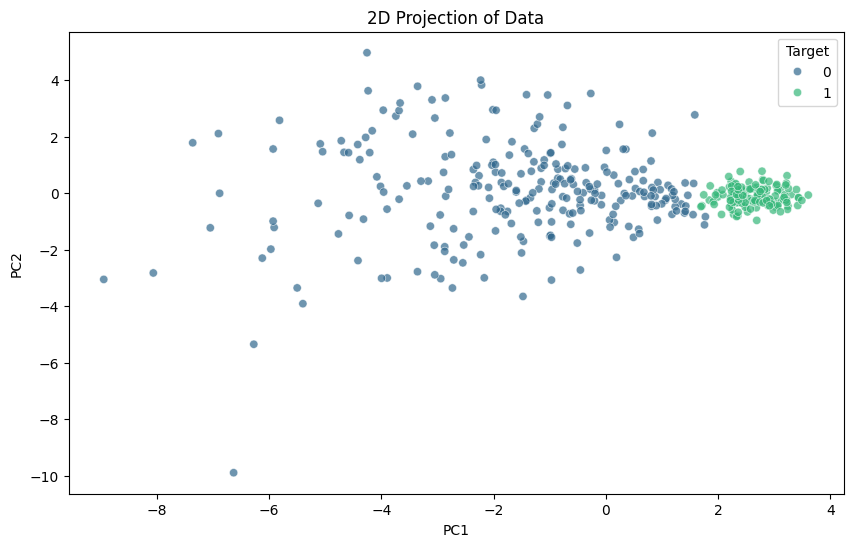

In [71]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pca2_df,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="viridis",
    alpha=0.7
)
plt.title("2D Projection of Data")
plt.show()

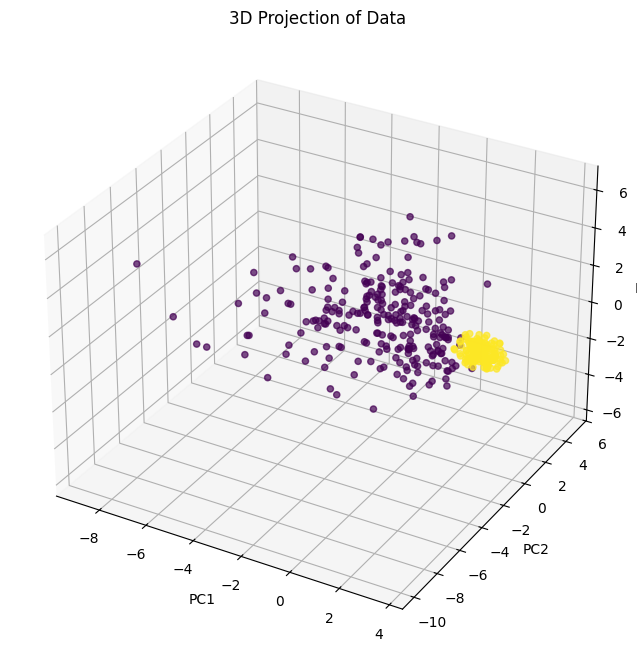

In [72]:
pca3 = PCA(n_components=3)
X_pca_3 = pca3.fit_transform(X_scaled)

pca3_df = pd.DataFrame(
    X_pca_3,
    columns=["PC1","PC2","PC3"]
)

pca3_df["Target"] = y.values

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca3_df["PC1"],
    pca3_df["PC2"],
    pca3_df["PC3"],
    c=pca3_df["Target"],
    cmap="viridis",
    marker="o",
    alpha=0.7
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("3D Projection of Data")
plt.show()

In [73]:
print("Variance Retained :",np.sum(pca_95.explained_variance_ratio_))
print("Original Shape :",X_scaled.shape)
print("Reduced Shape :",X_pca_95.shape)

Variance Retained : 0.5476646822288088
Original Shape : (400, 24)
Reduced Shape : (400, 5)


In [74]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify =y)


In [75]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
yprob = lr.predict_proba(X_test)[:,1]

accuracy_org  = accuracy_score(y_test, y_pred)
print("Accuracy", accuracy_org)

Accuracy 0.9875


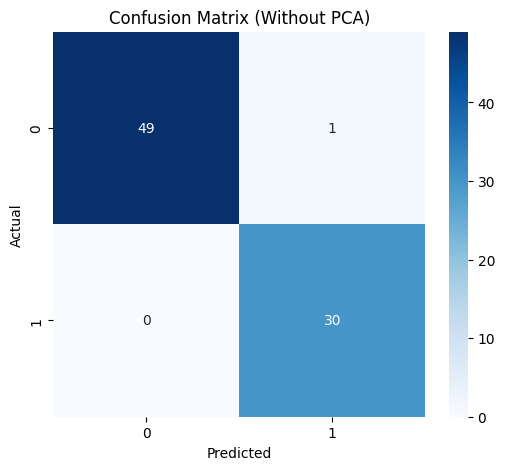

In [76]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix (Without PCA)")

plt.show()

In [77]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        50
           1       0.97      1.00      0.98        30

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



In [78]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca_95, y, test_size=0.2, random_state=42, stratify =y
    )

lr_pca = LogisticRegression(max_iter = 1000)
lr_pca.fit(X_train_pca, y_train_pca)

y_pred_pca = lr_pca.predict(X_test_pca)
yprob_pca = lr_pca.predict_proba(X_test_pca)[:,1]

accuracy_pca = accuracy_score(y_test_pca, y_pred_pca)
print("Accuracy", accuracy_pca)

Accuracy 0.975


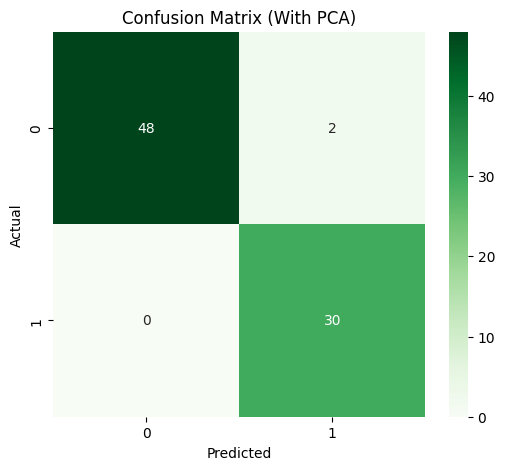

In [79]:
cm_pca = confusion_matrix(y_test_pca,y_pred_pca)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_pca,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix (With PCA)")

plt.show()

In [81]:
print(classification_report(y_test_pca,y_pred_pca))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98        50
           1       0.94      1.00      0.97        30

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80



In [83]:
comparison = pd.DataFrame({

    "Model":[
        "Without PCA",
        "With PCA"
    ],

    "Accuracy":[
        accuracy_org,
        accuracy_pca
    ]
})

comparison

,Model,Accuracy
0,Without PCA,0.9875
1,With PCA,0.9750


In [84]:
print("Original Feature Count :",X_scaled.shape[1])

print("Reduced Feature Count :",X_pca_95.shape[1])

print()

print("Accuracy Without PCA :",accuracy_org)

print("Accuracy With PCA :",accuracy_pca)

print()

print("Variance Retained :",round(np.sum(pca_95.explained_variance_ratio_),4))

Original Feature Count : 24
Reduced Feature Count : 5

Accuracy Without PCA : 0.9875
Accuracy With PCA : 0.975

Variance Retained : 0.5477


In [67]:
sample = X.iloc[[0]]

sample_scaled = scaler.transform(sample)

sample_pca = pca_95.transform(sample_scaled)

prediction = lr_pca.predict(sample_pca)

prediction_probability = lr_pca.predict_proba(sample_pca)

print("Prediction :",prediction[0])

print("Prediction Probability :",prediction_probability)

Prediction : 0
Prediction Probability : [[0.90295384 0.09704616]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
